# Longitudinal invariant $J$ — split integration past the bounce singularity

We estimate

$$
J \propto \int_0^{s^*} \sqrt{B^* - B(s)}\, ds
$$

with $s=0$ on the magnetic ridge and $s^*$ the bounce point where $B(s^*) = B^*$. Near $s^*$ the integrand is singular; we split at $s_{\mathrm{mid}} = s^*/2$ and on $[s_{\mathrm{mid}}, s^*]$ use $t = \sqrt{B^* - B(s)}$, so $2t\,dt = -B'(s)\,ds$ and

$$
\int_{s_{\mathrm{mid}}}^{s^*} \sqrt{B^* - B(s)}\, ds
 = \int_0^{t_{\mathrm{mid}}} \frac{2 t^2}{|B'(s(t))|}\, dt,
\quad t_{\mathrm{mid}} = \sqrt{B^* - B(s_{\mathrm{mid}})}.
$$

The notebook loads coils, traces $\hat{b}$, locates $s^*$, then integrates both halves with `QuadGK`.

### Cell 1 — Setup and initialization

Packages: ODE solver stack (`DifferentialEquations`), automatic differentiation (`ForwardDiff`), adaptive quadrature (`QuadGK`), spline interpolation (`DataInterpolations`), and `CairoMakie` for figures. `Coil.jl` supplies `eval_B` and coil IO.

**Environment:** add any missing packages once, e.g. `using Pkg; Pkg.add(["DifferentialEquations", "DataInterpolations", "QuadGK"])`.

In [5]:
using Pkg
Pkg.instantiate()
Pkg.activate("c:/Users/danie/Stellarator_Isodrasticity")
using DifferentialEquations
using LinearAlgebra
using ForwardDiff
using StaticArrays
using QuadGK
using GLMakie
using DataInterpolations

const REPO = raw"C:/Users/danie/Stellarator_Isodrasticity"
cd(REPO)

include(joinpath(REPO, "Coil.jl"))

const COIL_FILE = joinpath(REPO, "landreman_paul.json")
const NQUAD = 64

coils = get_coils_from_file(Float64, COIL_FILE, NQUAD)
length(coils)

  Activating project at `c:\Users\danie\Stellarator_Isodrasticity`


16

### Cell 2 — Core physics: $|B|$, its gradient, and Dual-safe Biot–Savart

`eval_B` comes from `Coil.jl`. For `ForwardDiff.gradient` we evaluate $|B|$ through a type-agnostic Biot–Savart loop (same pattern as `magnetic_ridge_3.jl`) so `Dual` numbers propagate without signature errors.

In [6]:
"""
    B_agnostic(cs, x)

Vector `B` at `x` for any scalar type (Float64 or ForwardDiff.Dual).
"""
function B_agnostic(cs::Vector{Coil{T}}, x::AbstractVector) where {T}
    Bacc = zeros(eltype(x), 3)
    for c in cs
        for (ri, Idri) in zip(c.rs, c.Idrs)
            δ = SVector(ri[1] - x[1], ri[2] - x[2], ri[3] - x[3])
            d = sqrt(δ[1]^2 + δ[2]^2 + δ[3]^2)
            Bacc .+= cross(δ, Idri) ./ (d^3)
        end
    end
    return SVector{3,eltype(x)}(Bacc[1], Bacc[2], Bacc[3])
end

"""
    norm_B(coils, r)

Scalar |B(r)|.
"""
norm_B(coils::Vector{Coil{T}}, r::AbstractVector) where {T} = norm(B_agnostic(coils, r))

"""
    grad_B(coils, r)

Gradient of |B| with respect to Cartesian r.
"""
function grad_B(coils::Vector{Coil{T}}, r::AbstractVector) where {T}
    x = SVector{3,Float64}(r[1], r[2], r[3])
    ForwardDiff.gradient(z -> norm_B(coils, z), x)
end

# Quick sanity check
r0 = SA[1.2, 0.05, 0.0]
norm_B(coils, r0), grad_B(coils, r0)

(1.0232102886765506, [-1.5431946226828595, -0.08053888504864837, -0.050334109710863426])

### Cell 2.5 — Surface parameterization bridge

Load the polynomial–Fourier ridge fit (`coeffs`, `M`, `N`) from Set 2 and define helpers that map cylindrical `(R, \phi)` to ridge-consistent Cartesian starts `SA[x, y, z]`.

### Cell 3 — Field-line tracing: $d\mathbf{r}/ds = \hat{b}$

Independent variable $s$ is arc length. State $\mathbf{u} = (x,y,z)$. We integrate with `Tsit5` and dense output on a uniform grid in $s$ so $B(s)$ is well resolved for splines.

In [7]:
using JLD2

const RIDGE_COEFFS_FILE = "C:/Users/danie/Stellarator_Isodrasticity/data/ridge_coeffs.jld2"

coeffs, M, N = jldopen(RIDGE_COEFFS_FILE, "r") do f
    Vector{Float64}(f["coeffs"]), Int(f["M"]), Int(f["N"])
end

"""
    evaluate_ridge_z(R, phi, coeffs, M, N)

Evaluate z(R, phi) using the polynomial–Fourier basis
z = sum_{m=0}^M R^m [A_{m,0} + sum_{n=1}^N (A_{m,n} cos(n phi) + B_{m,n} sin(n phi))].
"""
function evaluate_ridge_z(R::Float64, phi::Float64, coeffs::AbstractVector{<:Real}, M::Int, N::Int)
    z = 0.0
    k = 1

    # n = 0 block: A_{m,0}
    for m in 0:M
        z += coeffs[k] * (R^m)
        k += 1
    end

    # n >= 1 blocks: A_{m,n} cos(n phi), then B_{m,n} sin(n phi)
    for n in 1:N
        cn = cos(n * phi)
        sn = sin(n * phi)
        for m in 0:M
            Rm = R^m
            z += coeffs[k] * Rm * cn
            k += 1
            z += coeffs[k] * Rm * sn
            k += 1
        end
    end

    return z
end

"""
    get_starting_point(R, phi)

Return ridge-consistent initial point SA[x, y, z] from cylindrical (R, phi).
"""
function get_starting_point(R::Float64, phi::Float64)
    z = evaluate_ridge_z(R, phi, coeffs, M, N)
    x = R * cos(phi)
    y = R * sin(phi)
    SA[x, y, z]
end

# Quick bridge sanity check
get_starting_point(1.15, 0.3)

3-element SVector{3, Float64} with indices SOneTo(3):
 1.0986369624944468
 0.33984823766054045
 0.05909155238171293

### Cell 3 — Phase 1 Visual Proof (Isodrasticity Contours)

This cell reconstructs a trimmed analytical ridge surface using a nearest-point mask from raw `(new_rx, new_ry)` samples and overlays magnetic-field-strength contours to visually check whether `|B|` level sets align with the segmented ridge geometry.

Mask threshold used: 0.1 | valid grid points: 112591 / 153600
|B| range on valid surface: [0.785988, 6.011367]


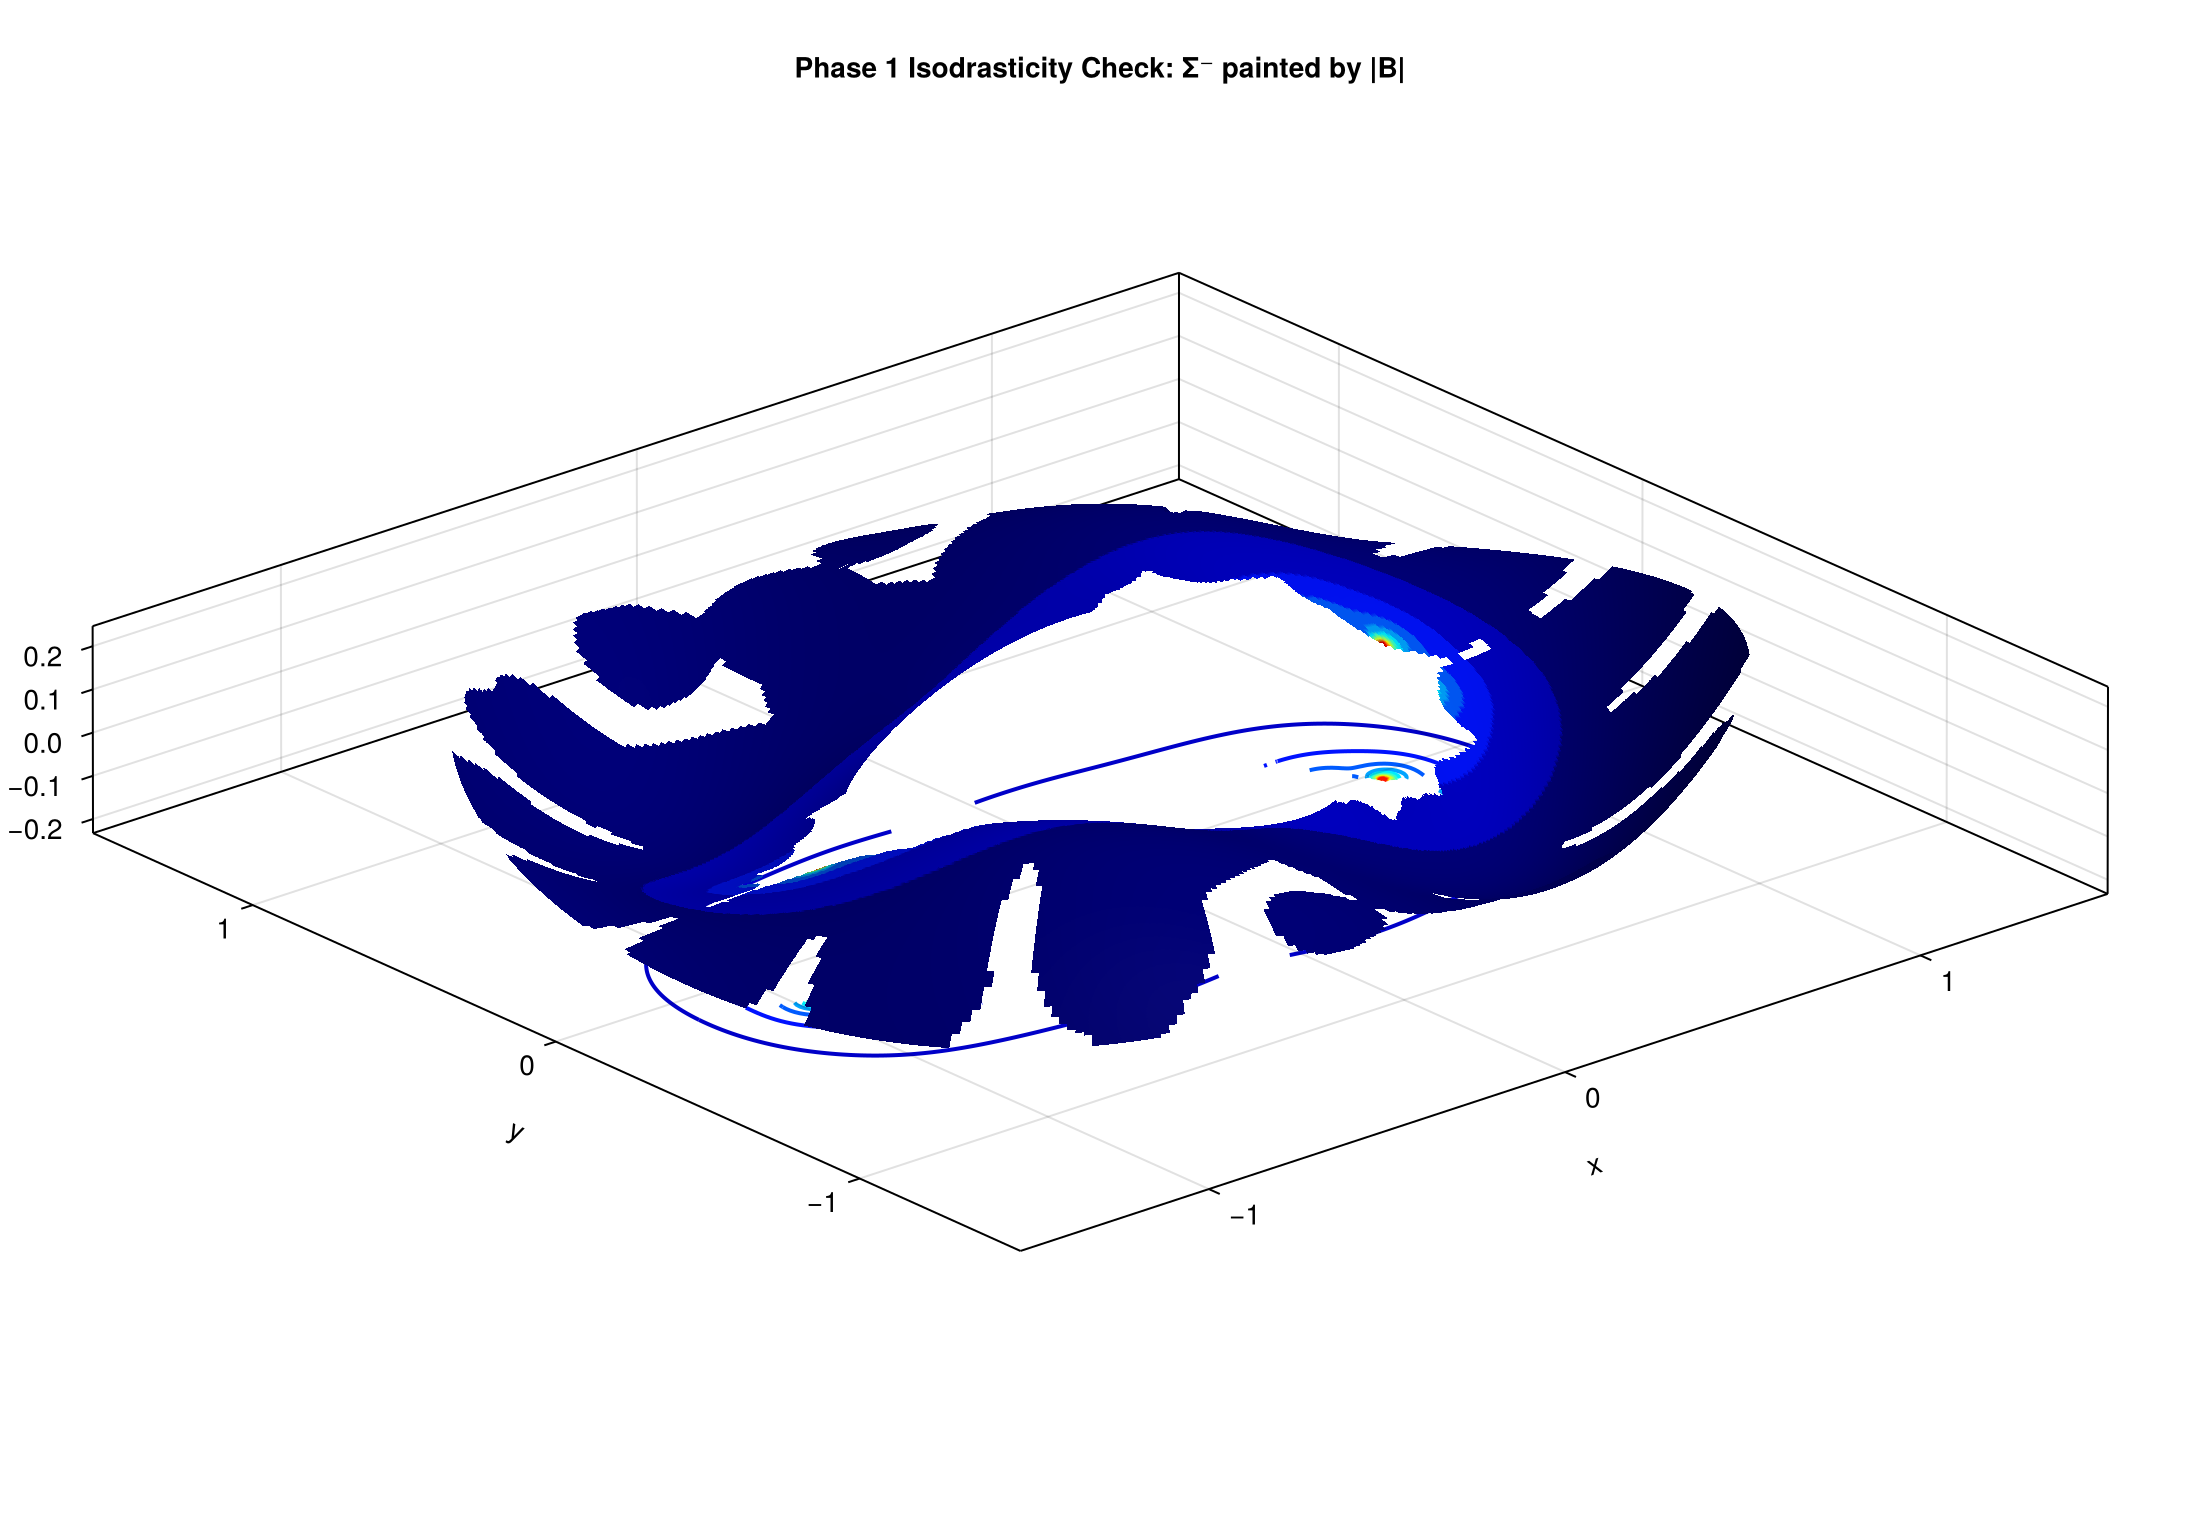

In [8]:
ridge_mask_file = joinpath(REPO, "data", "magnetic_ridge3", "magnetic_ridge_3.jld2")
new_rx, new_ry = jldopen(ridge_mask_file, "r") do f
    rx_key = haskey(f, "new_rx") ? "new_rx" : "ridge_x"
    ry_key = haskey(f, "new_ry") ? "new_ry" : "ridge_y"
    Vector{Float64}(f[rx_key]), Vector{Float64}(f[ry_key])
end

R_mask = hypot.(new_rx, new_ry)
R_min, R_max = extrema(R_mask)

nR = 320
nphi = 480
R_vals = range(R_min, R_max; length = nR)
phi_vals = range(-π, π; length = nphi)

R_grid = [R for R in R_vals, _ in phi_vals]
Phi_grid = [phi for _ in R_vals, phi in phi_vals]
X_surface = R_grid .* cos.(Phi_grid)
Y_surface = R_grid .* sin.(Phi_grid)

function build_masked_surfaces!(Z_surface, B_mag_surface, X_surface, Y_surface, R_grid, Phi_grid, new_rx, new_ry, th)
    fill!(Z_surface, NaN)
    fill!(B_mag_surface, NaN)
    th2 = th^2

    nR, nphi = size(Z_surface)
    for i in 1:nR
        for j in 1:nphi
            x = X_surface[i, j]
            y = Y_surface[i, j]
            d2_min = minimum((new_rx .- x).^2 .+ (new_ry .- y).^2)

            if d2_min < th2
                R = R_grid[i, j]
                phi = Phi_grid[i, j]
                z = evaluate_ridge_z(R, phi, coeffs, M, N)
                Z_surface[i, j] = z
                B_mag_surface[i, j] = norm_B(coils, SA[x, y, z])
            end
        end
    end

    count(.!isnan.(Z_surface))
end

Z_surface = fill(NaN, nR, nphi)
B_mag_surface = fill(NaN, nR, nphi)

# Looser mask for less fragmented trimmed geometry
threshold_candidates = (0.10, 0.14, 0.20, 0.28)
used_threshold = threshold_candidates[1]
valid_count = 0
for th in threshold_candidates
    valid_count = build_masked_surfaces!(Z_surface, B_mag_surface, X_surface, Y_surface, R_grid, Phi_grid, new_rx, new_ry, th)
    used_threshold = th
    valid_count > 0 && break
end

valid_count > 0 || error("Phase 1 mask produced zero valid points. Increase threshold or check mask dataset keys.")
valid_B = B_mag_surface[.!isnan.(B_mag_surface)]
b_min, b_max = extrema(valid_B)
levels_B = length(valid_B) > 15 ? range(b_min, b_max; length = 15) : 8
banded_cmap = cgrad(:jet, 15, categorical = true)

fig_phase1 = Figure(size = (1100, 760))
ax_phase1 = Axis3(
    fig_phase1[1, 1];
    title = "Phase 1 Isodrasticity Check: Σ⁻ painted by |B|",
    xlabel = "x",
    ylabel = "y",
    zlabel = "z",
    aspect = :data,
)

# Paint |B| directly on the physical surface geometry with tight color scaling
surface!(
    ax_phase1,
    X_surface,
    Y_surface,
    Z_surface;
    color = B_mag_surface,
    colormap = banded_cmap,
    colorrange = (b_min, b_max),
    nan_color = RGBAf(0, 0, 0, 0),
    shading = true,
)

# Optional floor-projected contours to inspect contour closure
z_floor = minimum(Z_surface[.!isnan.(Z_surface)]) - 0.08
contour!(
    ax_phase1,
    X_surface,
    Y_surface,
    B_mag_surface;
    levels = levels_B,
    colormap = banded_cmap,
    linewidth = 2,
    transformation = (:xy, z_floor),
)

println("Mask threshold used: ", used_threshold, " | valid grid points: ", valid_count, " / ", length(Z_surface))
println("|B| range on valid surface: [", round(b_min; digits = 6), ", ", round(b_max; digits = 6), "]")
fig_phase1

In [9]:
function field_rhs!(du, u, p, s)
    B = B_agnostic(p.coils, u)
    nb = norm(B)
    nb < eps(Float64) * 1e8 && (du .= 0; return)
    b = B / nb
    du[1], du[2], du[3] = b[1], b[2], b[3]
    nothing
end

"""
    trace_field_line(coils, R, phi, s_max; n = 4000, B_star = nothing)

Build a ridge-consistent start point from `(R, phi)`, then return `(s, B_mag)`
with `B_mag[i] = |B(u(s_i))|`.

If `B_star` is provided, a `ContinuousCallback` terminates the ODE at the first
bounce root `|B(u)| - B_star = 0`.
"""
function trace_field_line(coils, R::Float64, phi::Float64, s_max::Float64; n::Int = 4000, B_star = nothing)
    u0 = get_starting_point(R, phi)
    u0v = collect(Float64, u0)
    prob = ODEProblem(field_rhs!, u0v, (0.0, s_max), (; coils))

    solve_kwargs = (
        abstol = 1e-10,
        reltol = 1e-10,
        save_everystep = true,
    )

    sol = if isnothing(B_star)
        st = range(0.0, s_max; length = n)
        solve(
            prob,
            Tsit5();
            saveat = st,
            solve_kwargs...,
        )
    else
        condition(u, s, integrator) = norm_B(integrator.p.coils, u) - B_star
        affect!(integrator) = terminate!(integrator)
        cb = ContinuousCallback(condition, affect!; rootfind = true)
        solve(
            prob,
            Tsit5();
            callback = cb,
            tstops = [s_max],
            solve_kwargs...,
        )
    end

    s = collect(sol.t)
    B_mag = Float64[]
    sizehint!(B_mag, length(sol.u))
    for u in sol.u
        push!(B_mag, norm_B(coils, u))
    end
    return s, B_mag
end

# Example trace from magnetic ridge parameterization
phi = 0.3
R0 = 1.15
s_max = 80.0
u_start = get_starting_point(R0, phi)
s_data, B_data = trace_field_line(coils, R0, phi, s_max; n = 3000)

fig_trace = Figure(size = (900, 360))
ax_trace = Axis(
    fig_trace[1, 1];
    xlabel = "s (arc length)",
    ylabel = "|B|",
    title = "Field-line trace diagnostic: |B(s)|",
)
lines!(ax_trace, s_data, B_data; color = :black, linewidth = 1.6)
fig_trace

(u_start, length(s_data), extrema(B_data))

([1.0986369624944468, 0.33984823766054045, 0.05909155238171293], 3000, (0.9579207248593996, 1.0558787899103472))

### Cell 4 — Bounce point $s^*$ where $B(s^*) = B^*$

On the discrete trace, build a smooth spline $B(s)$, then bracket and refine the root of $B(s) - B^* = 0$. We assume there is a solution with $s^* > 0$ and that $B^*$ lies between $B(0)$ and $\max B$ along the segment of interest (adjust `B_star` otherwise).

In [10]:
"""
    spline_B_of_s(s_data, B_data)

Cubic spline with nodes sorted by `s`.
"""
function spline_B_of_s(s_data::Vector{Float64}, B_data::Vector{Float64})
    p = sortperm(s_data)
    s_sorted = s_data[p]
    B_sorted = B_data[p]
    # strictly increasing knots for CubicSpline (merge near-duplicates)
    s_out = Float64[s_sorted[1]]
    B_out = Float64[B_sorted[1]]
    for i in 2:length(s_sorted)
        if s_sorted[i] > s_out[end] + 1e-12
            push!(s_out, s_sorted[i])
            push!(B_out, B_sorted[i])
        else
            B_out[end] = B_sorted[i]
        end
    end
    length(s_out) ≥ 4 || error("Need at least 4 spline knots after deduplication")
    CubicSpline(B_out, s_out)
end

B_of_s(S::CubicSpline, s::Float64) = S(s)

"""
    B_prime_from_spline(S, s)

Derivative dB/ds using `DataInterpolations.derivative`.
"""
B_prime_from_spline(S::CubicSpline, s::Float64) = DataInterpolations.derivative(S, s)

"""
    find_bounce_arclength(s_data, B_data, B_star)

Returns `s_star` with `B(s_star) ≈ B_star` (first crossing found by scanning).
"""
function find_bounce_arclength(s_data::Vector{Float64}, B_data::Vector{Float64}, B_star::Float64)
    S = spline_B_of_s(s_data, B_data)
    smin, smax = extrema(s_data)
    g(s) = B_of_s(S, s) - B_star
    # bracket: look for sign change on spline grid
    ss = range(smin, smax; length = max(200, length(s_data)))
    local a::Float64, b::Float64
    a, b = smin, smax
    found = false
    gs = g.(ss)
    for i in 1:(length(ss)-1)
        if gs[i] == 0
            return ss[i]
        end
        if gs[i] * gs[i+1] < 0
            a, b = ss[i], ss[i+1]
            found = true
            break
        end
    end
    found || error("Could not bracket B(s) = B_star; check B_star lies between min/max B along trace.")
    for _ in 1:60
        m = (a + b) / 2
        if g(a) * g(m) ≤ 0
            b = m
        else
            a = m
        end
        if abs(b - a) < 1e-12 * (1 + abs(m))
            return (a + b) / 2
        end
    end
    return (a + b) / 2
end

# Pick a bounce level above the starting |B|
B_star = B_data[1] + 0.35 * (maximum(B_data) - B_data[1])
S_bounce = spline_B_of_s(s_data, B_data)
s_star = find_bounce_arclength(s_data, B_data, B_star)

fig_bounce = Figure(size = (900, 360))
ax_bounce = Axis(
    fig_bounce[1, 1];
    xlabel = "s (arc length)",
    ylabel = "|B|",
    title = "Bounce root diagnostic: B(s) with B* and s*",
)
lines!(ax_bounce, s_data, B_data; color = :black, linewidth = 1.4)
hlines!(ax_bounce, [B_star]; color = :blue, linestyle = :dash)
vlines!(ax_bounce, [s_star]; color = :red, linestyle = :dash)
scatter!(ax_bounce, [s_star], [B_of_s(S_bounce, s_star)]; color = :red, markersize = 10)
fig_bounce

(B_star, s_star, B_of_s(S_bounce, s_star))

(1.0510851103400516, 13.675507217945011, 1.0510851103400092)

### Cell 5 — Split integration for $J \propto \int_0^{s^*} \sqrt{B^* - B(s)}\, ds$

- **Left:** $\int_0^{s_{\mathrm{mid}}} \sqrt{B^* - B(s)}\, ds$ with $s_{\mathrm{mid}} = s^*/2$.
- **Right:** $\int_{t_{\mathrm{mid}}}^{0} \frac{2 t^2}{|B'(s)|}\, dt$ with $t = \sqrt{B^* - B(s)}$, mapping each $t$ to $s \in [s_{\mathrm{mid}}, s^*]$ by solving $B(s) = B^* - t^2$ (bisection, monotone segment).

We use the same cubic spline for $B(s)$ and its analytic derivative from `DataInterpolations`.

In [11]:
"""
    s_from_t_target(S, B_star, t, slo, shi)

Find `s ∈ [slo, shi]` such that `B(s) = B_star - t^2`.
"""
function s_from_t_target(S::CubicSpline, B_star::Float64, t::Float64, slo::Float64, shi::Float64)
    target = B_star - t^2
    h(s) = B_of_s(S, s) - target
    ha, hb = h(slo), h(shi)
    ha * hb ≤ 0 || error("B(s)=B_star-t^2 not bracketed; check monotonicity on [slo, shi]")
    a, b = slo, shi
    for _ in 1:80
        m = (a + b) / 2
        hm = h(m)
        abs(hm) < 1e-14 * (1 + abs(target)) && return m
        if ha * hm ≤ 0
            b, hb = m, hm
        else
            a, ha = m, hm
        end
        abs(b - a) < 1e-13 * (1 + abs(m)) && return (a + b) / 2
    end
    return (a + b) / 2
end

"""
    calculate_J(s_data, B_data, B_star; atol=1e-8)

Returns `(J_estimate, s_star, s_mid, left_part, right_part, S)`.
"""
function calculate_J(s_data::Vector{Float64}, B_data::Vector{Float64}, B_star::Float64; atol::Float64 = 1e-8)
    S = spline_B_of_s(s_data, B_data)
    s_star = find_bounce_arclength(s_data, B_data, B_star)
    s_mid = s_star / 2

    B0 = B_of_s(S, 0.0)
    B_star - B0 < 0 && error("Need B_star ≥ B(0) for nonnegative integrand on [0,s*]")

    smin, smax = extrema(s_data)
    (0 ≤ s_mid ≤ s_star) || error("s_mid out of range")

    left_integrand(s) = sqrt(max(B_star - B_of_s(S, s), 0.0))
    L, el = quadgk(left_integrand, 0.0, s_mid; atol = atol, rtol = atol)

    t_mid = sqrt(max(B_star - B_of_s(S, s_mid), 0.0))
    function right_integrand(t)
        t ≤ 0 && return 0.0
        sc = s_from_t_target(S, B_star, t, s_mid, s_star)
        Bp = B_prime_from_spline(S, sc)
        den = max(abs(Bp), 1e-30)
        return 2 * t^2 / den
    end
    # integrate t from t_mid down to 0 ⇒ swap limits
    R, er = quadgk(right_integrand, 0.0, t_mid; atol = atol, rtol = atol)

    J = L + R
    return (; J, s_star, s_mid, left = L, right = R, spline = S, t_mid, el, er)
end

res = calculate_J(s_data, B_data, B_star)
(res.J, res.left, res.right, res.s_star, res.s_mid)

(2.975535817103541, 1.540757810746555, 1.4347780063569864, 13.675507217945011, 6.8377536089725055)

### Cell 6 — Visualization

**Plot 1:** $B(s)$ with vertical lines at $0$, $s_{\mathrm{mid}}$, $s^*$.

**Plot 2:** Phase-space style curves $v_\parallel = \pm \sqrt{B^* - B(s)}$ vs $s$ (only real where $B^* \geq B(s)$).

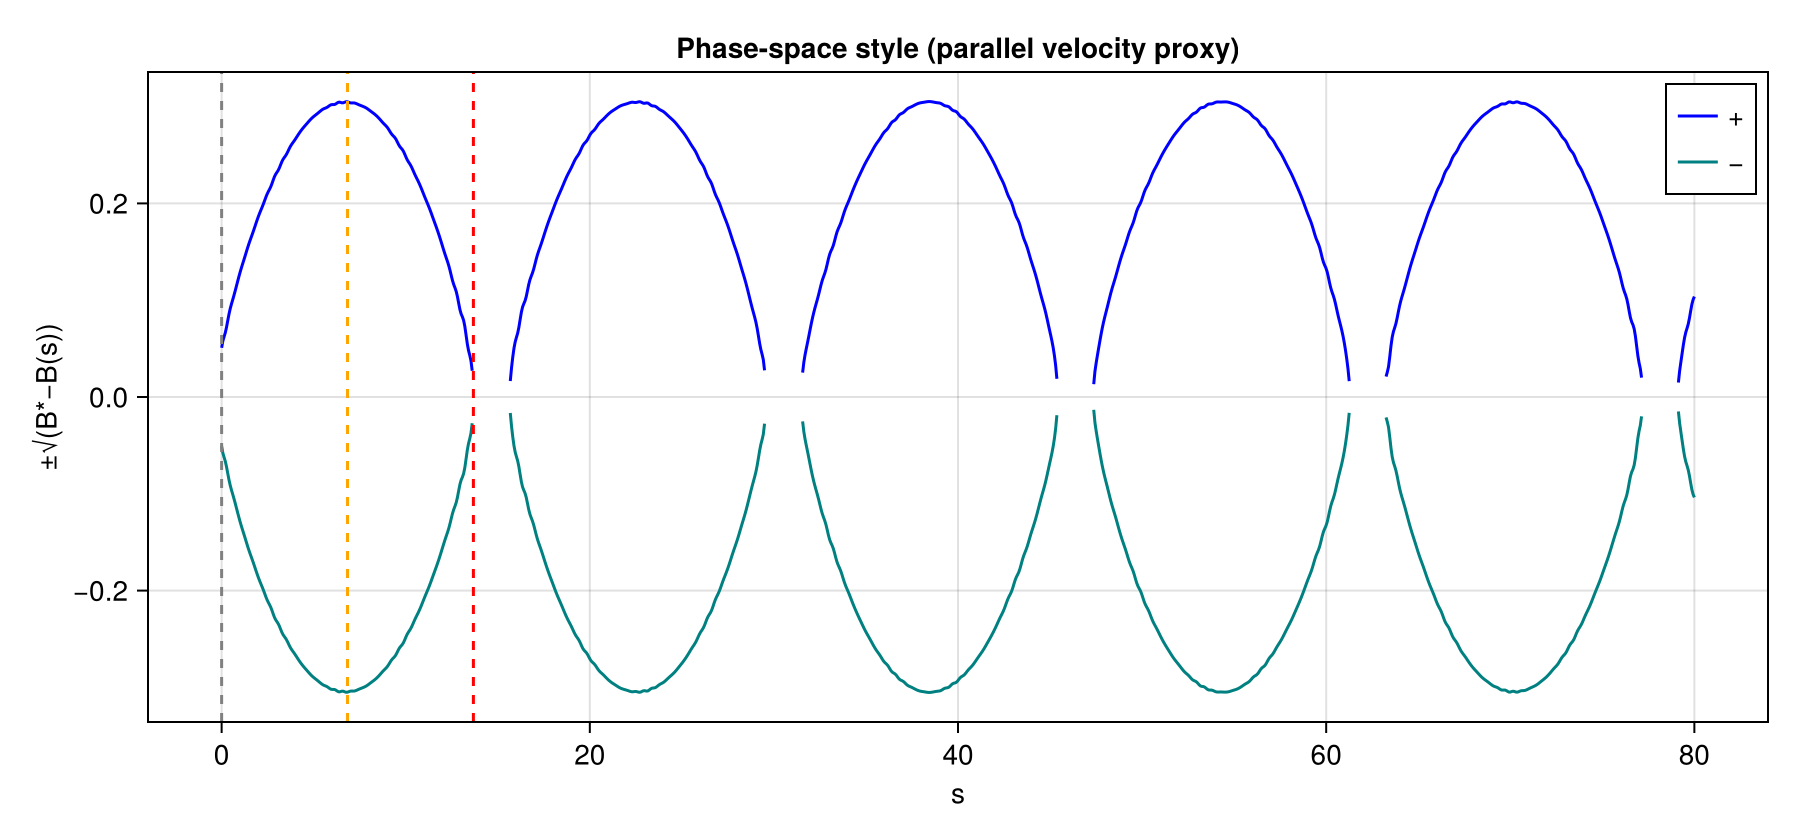

In [15]:
Splot = spline_B_of_s(s_data, B_data)
ss_fine = range(s_data[1], s_data[end]; length = 1200)
Bfine = [B_of_s(Splot, s) for s in ss_fine]

fig1 = Figure(size = (900, 420))
ax1 = Axis(
    fig1[1, 1];
    xlabel = "s (arc length)",
    ylabel = "|B|",
    title = "|B(s)| along field line — B* = $(round(B_star; digits=4))",
)
lines!(ax1, collect(ss_fine), Bfine; color = :black, linewidth = 1.5)
vlines!(ax1, [0.0]; color = :gray, linestyle = :dash, linewidth = 2)
vlines!(ax1, [res.s_mid]; color = :orange, linestyle = :dash, linewidth = 2)
vlines!(ax1, [res.s_star]; color = :red, linestyle = :dash, linewidth = 2)
fig1

# Phase-space style: v_parallel = ± sqrt(B* - B(s))
v_plus = Float64[]
v_minus = Float64[]
for s in ss_fine
    Bs = B_of_s(Splot, s)
    dv = B_star - Bs
    if dv ≥ 0
        v = sqrt(dv)
        push!(v_plus, v)
        push!(v_minus, -v)
    else
        push!(v_plus, NaN)
        push!(v_minus, NaN)
    end
end

fig2 = Figure(size = (900, 420))
ax2 = Axis(fig2[1, 1]; xlabel = "s", ylabel = "±√(B*−B(s))", title = "Phase-space style (parallel velocity proxy)")
lp = lines!(ax2, collect(ss_fine), v_plus; color = :blue, linewidth = 1.5)
lm = lines!(ax2, collect(ss_fine), v_minus; color = :teal, linewidth = 1.5)
vlines!(ax2, [0.0]; color = :gray, linestyle = :dash)
vlines!(ax2, [res.s_mid]; color = :orange, linestyle = :dash)
vlines!(ax2, [res.s_star]; color = :red, linestyle = :dash)
axislegend(ax2, [lp, lm], ["+", "−"]; position = :rt)
fig2

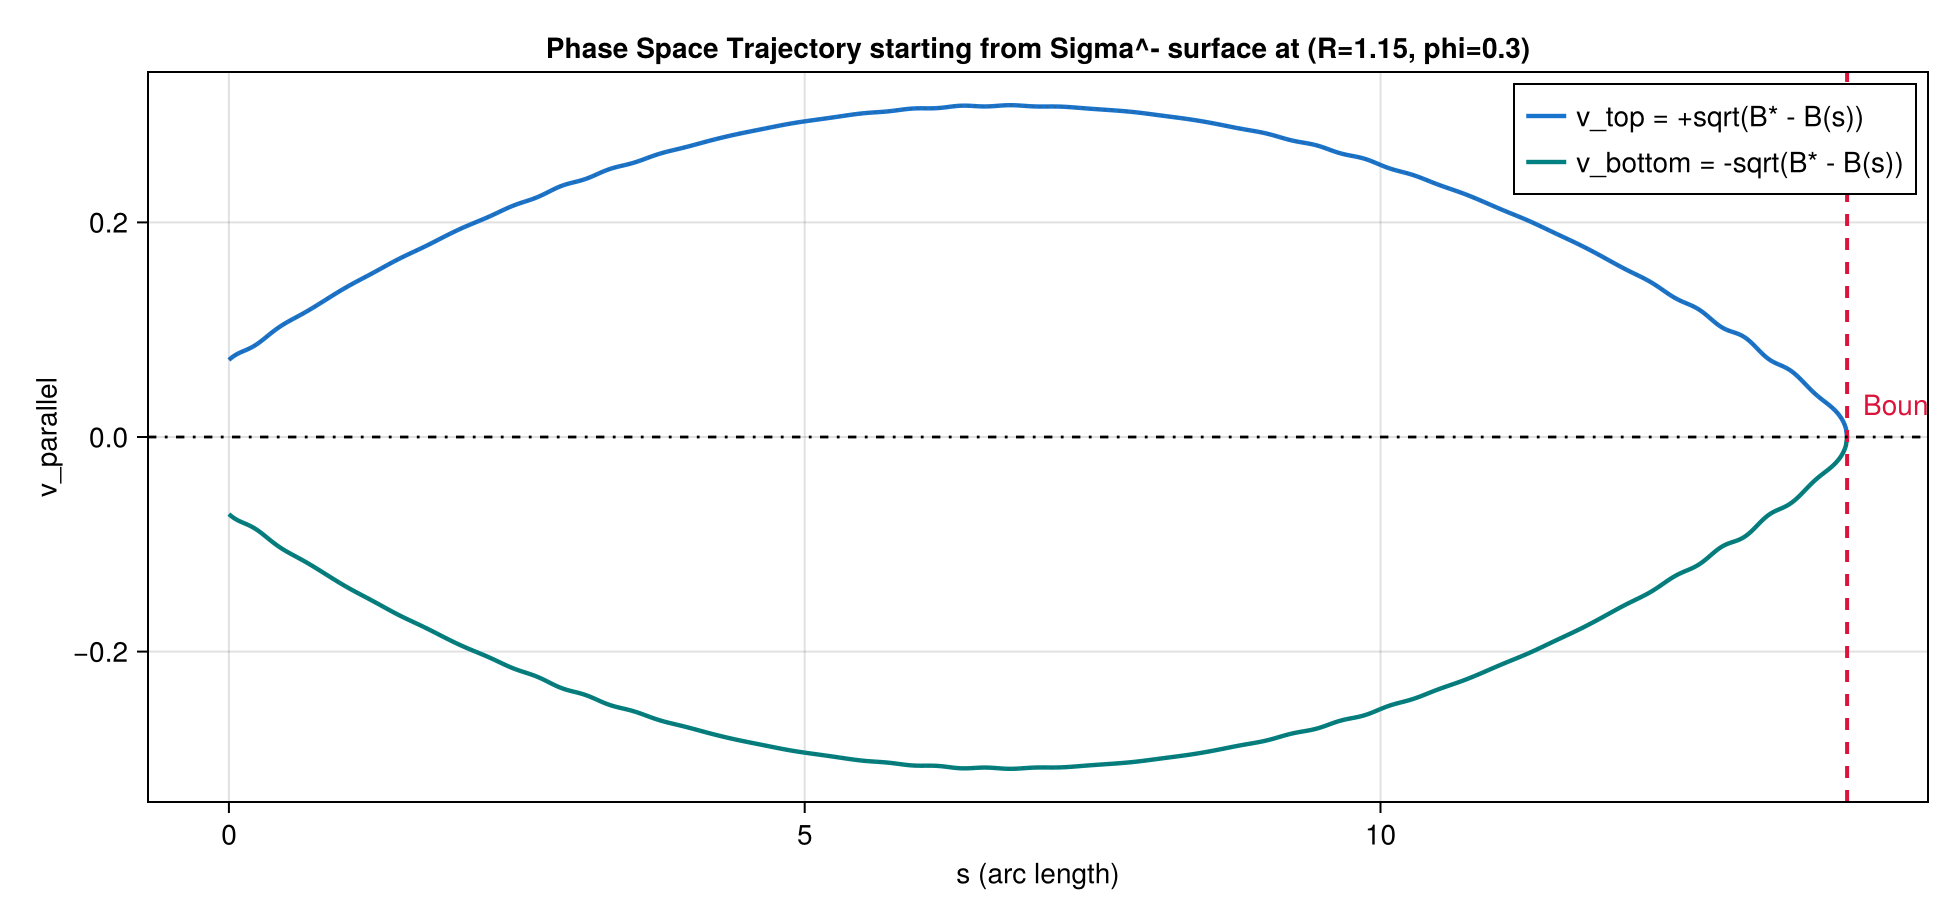

u0_teardrop = [1.0986369624944468, 0.33984823766054045, 0.05909155238171293]
B0_td       = 1.0485039
B_star_td   = 1.05366768
s_star_td   = 14.0517802


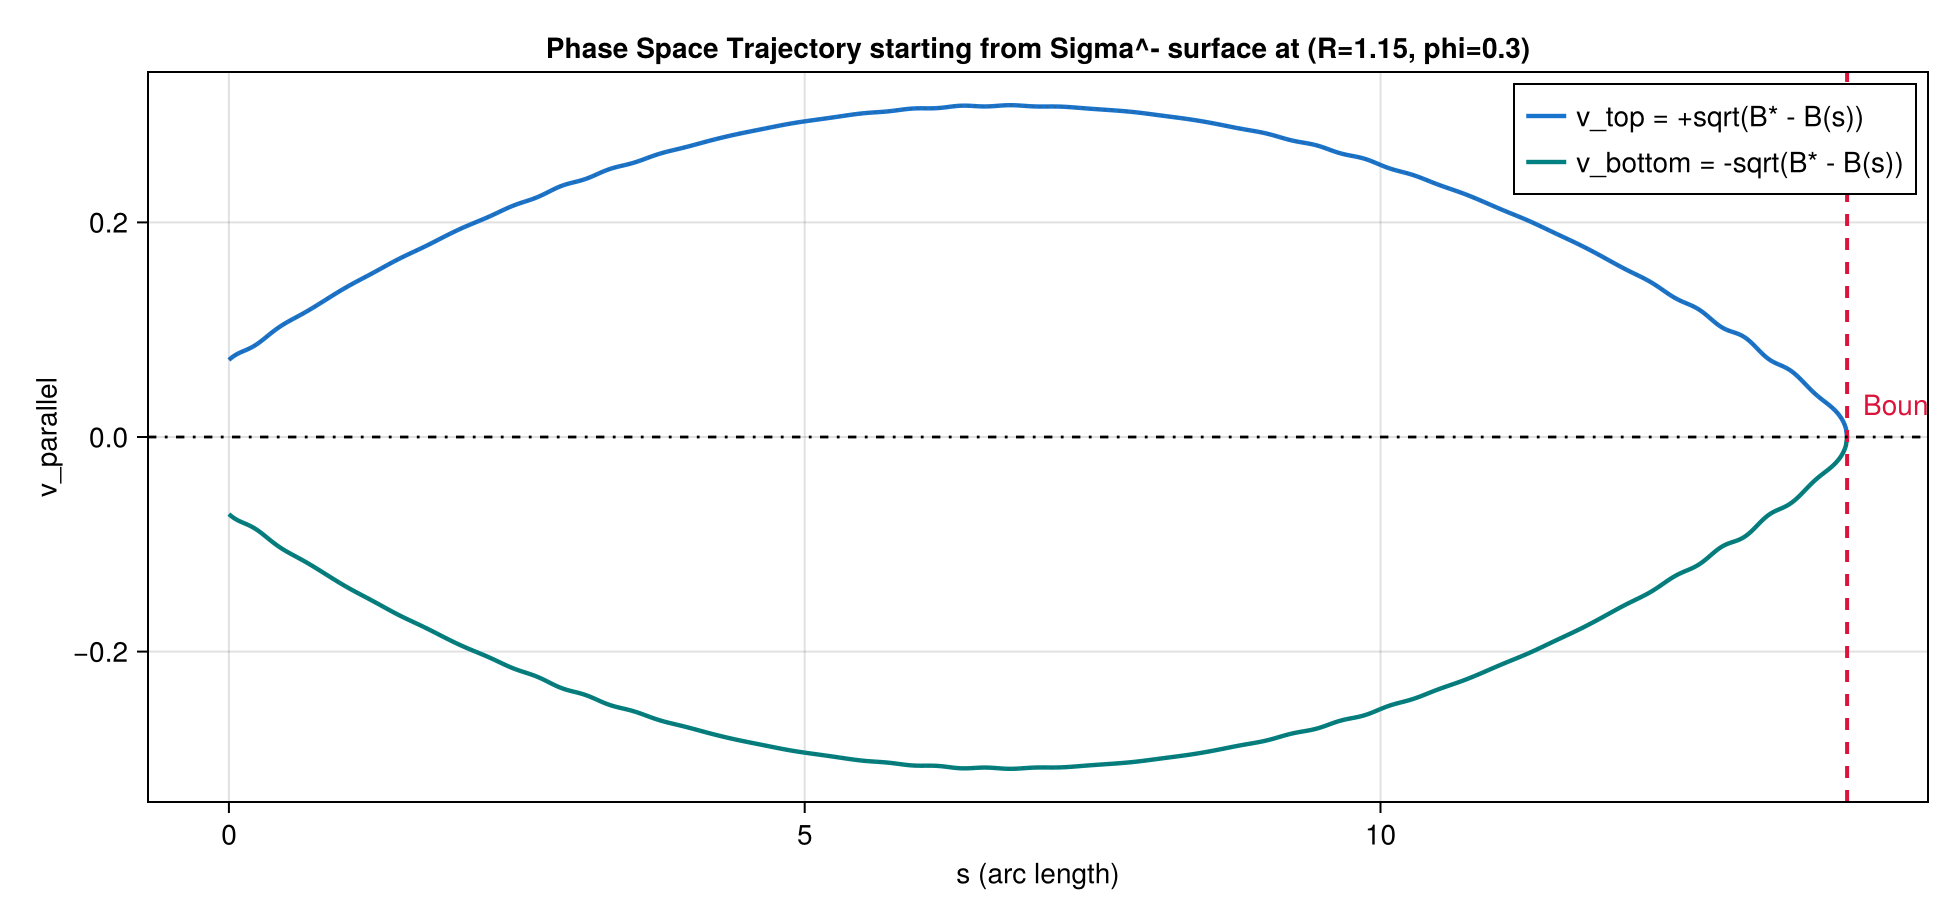

In [18]:
### Cell 7 — Phase Space Teardrop diagnostic from a Σ⁻ starting point

# 1) Pick a known Σ⁻ segment point (same ridge-consistent segment used above)
R_teardrop = 1.15
phi_teardrop = 0.3
u0_teardrop = get_starting_point(R_teardrop, phi_teardrop)

# 2) Preliminary trace to pick a robust trapped-particle B*
s_max_teardrop = 80.0
s_pre, B_pre = trace_field_line(coils, R_teardrop, phi_teardrop, s_max_teardrop; n = 4000)

# 3) Set trapped-particle energy level B* slightly above B(0),
#    but safely below max(B) so a first-bounce crossing is guaranteed.
B0_td = B_pre[1]
Bmax_td = maximum(B_pre)
ΔB_request = 0.05
ΔB_available = Bmax_td - B0_td
ΔB_available > 1e-12 || error("Trace has almost no B variation; cannot define trapped branch.")

ΔB_td = min(ΔB_request, 0.7 * ΔB_available)
ΔB_td = max(ΔB_td, 0.05 * ΔB_available)
B_star_td = B0_td + ΔB_td

# Re-trace with callback termination at first bounce |B| = B_star_td.
# Keep this local helper to avoid dependency on whether an earlier cell
# redefined trace_field_line with the B_star keyword.
function trace_field_line_to_bounce(coils, R::Float64, phi::Float64, s_max::Float64, B_star::Float64)
    u0 = get_starting_point(R, phi)
    u0v = collect(Float64, u0)
    prob = ODEProblem(field_rhs!, u0v, (0.0, s_max), (; coils))

    condition(u, s, integrator) = norm_B(integrator.p.coils, u) - B_star
    affect!(integrator) = terminate!(integrator)
    cb = ContinuousCallback(condition, affect!; rootfind = true)

    sol = solve(
        prob,
        Tsit5();
        callback = cb,
        tstops = [s_max],
        abstol = 1e-10,
        reltol = 1e-10,
        save_everystep = true,
    )

    s = collect(sol.t)
    B_mag = [norm_B(coils, u) for u in sol.u]
    return s, B_mag
end

s_td, B_td = trace_field_line_to_bounce(coils, R_teardrop, phi_teardrop, s_max_teardrop, B_star_td)
s_star_td = s_td[end]
abs(B_td[end] - B_star_td) < 1e-6 || error("Callback did not terminate at bounce; increase s_max or adjust B_star.")

# 4) Build teardrop data strictly on [0, s*]
S_td = spline_B_of_s(s_td, B_td)
s_fine_td = range(0.0, s_star_td; length = 1400)
v_top_td = Float64[]
v_bottom_td = Float64[]
sizehint!(v_top_td, length(s_fine_td))
sizehint!(v_bottom_td, length(s_fine_td))

for s in s_fine_td
    dv = B_star_td - B_of_s(S_td, s)
    v = sqrt(max(dv, 0.0))
    push!(v_top_td, v)
    push!(v_bottom_td, -v)
end

# Closed eye/teardrop polyline: top branch forward, bottom branch backward
s_closed = vcat(collect(s_fine_td), reverse(collect(s_fine_td)))
v_closed = vcat(v_top_td, reverse(v_bottom_td))

# 5) Plot phase-space teardrop with bounce and v=0 guides
fig_td = Figure(size = (980, 460))
ax_td = Axis(
    fig_td[1, 1];
    xlabel = "s (arc length)",
    ylabel = "v_parallel",
    title = "Phase Space Trajectory starting from Sigma^- surface at (R=$(round(R_teardrop; digits=3)), phi=$(round(phi_teardrop; digits=3)))",
)

lines!(ax_td, s_fine_td, v_top_td; color = :dodgerblue3, linewidth = 2.2, label = "v_top = +sqrt(B* - B(s))")
lines!(ax_td, s_fine_td, v_bottom_td; color = :teal, linewidth = 2.2, label = "v_bottom = -sqrt(B* - B(s))")
lines!(ax_td, s_closed, v_closed; color = (:gray30, 0.35), linewidth = 1.2, linestyle = :dot)

vlines!(ax_td, [s_star_td]; color = :crimson, linestyle = :dash, linewidth = 2.0)
hlines!(ax_td, [0.0]; color = :black, linestyle = :dashdot, linewidth = 1.4)
text!(ax_td, s_star_td, 0.0; text = "Bounce Point", color = :crimson, align = (:left, :bottom), offset = (8, 8))

axislegend(ax_td; position = :rt)
display(fig_td)

println("u0_teardrop = ", u0_teardrop)
println("B0_td       = ", round(B0_td; digits = 8))
println("B_star_td   = ", round(B_star_td; digits = 8))
println("s_star_td   = ", round(s_star_td; digits = 8))

fig_td

In [19]:
### Phase 2: Isodrasticity Verification Scan

using Statistics

"""
    compute_J_at(R, phi, B_star; s_max=80.0, ntrace=3500, atol=1e-8)

Trace one field line launched from the ridge point `(R, phi)` and compute `J`
with the split-integral method for a chosen absolute bounce level `B_star`.
"""
function compute_J_at(R::Float64, phi::Float64, B_star::Float64; s_max::Float64 = 80.0, ntrace::Int = 3500, atol::Float64 = 1e-8)
    u0 = get_starting_point(R, phi)
    s_data, B_data = trace_field_line(coils, R, phi, s_max; n = ntrace)

    B0 = B_data[1]
    Bmax = maximum(B_data)
    B_star < B0 && error("B_star < B(0): no trapped branch from launch point")
    B_star > Bmax && error("B_star > max(B(s)): no bounce crossing on traced segment")

    res_local = calculate_J(s_data, B_data, B_star; atol = atol)
    return (; J = res_local.J, s_star = res_local.s_star, B0, Bmax, u0)
end

# 1) Define target contour level on Sigma^- from Phase 1 field map
valid_B2 = B_mag_surface[.!isnan.(B_mag_surface)]
bmin2, bmax2 = extrema(valid_B2)
B_target = bmin2 + 0.10 * (bmax2 - bmin2)   # slightly above minimum on the ridge

# Build a common bounce level above that contour for all points
ΔB_scan = 0.05
B_star_scan = B_target + ΔB_scan

# 2) Extract contour-like points from (R_grid, Phi_grid, B_mag_surface)
# Strategy: sample toroidal angles, then in each phi-column pick R with |B - B_target| minimum.
n_scan = 16
phi_targets = range(-π, π; length = n_scan + 2)[2:end-1]
phi_cols = vec(Phi_grid[1, :])

R_scan = Float64[]
phi_scan = Float64[]
B0_scan = Float64[]

for φt in phi_targets
    j = argmin(abs.(phi_cols .- φt))
    colB = B_mag_surface[:, j]
    valid_i = findall(!isnan, colB)
    isempty(valid_i) && continue

    local_i = valid_i[argmin(abs.(colB[valid_i] .- B_target))]
    push!(R_scan, R_grid[local_i, j])
    push!(phi_scan, Phi_grid[local_i, j])
    push!(B0_scan, colB[local_i])
end

npts = length(R_scan)
npts > 0 || error("No contour points found for B_target. Try changing B_target fraction.")

println("Phase 2 setup")
println("  B_target = ", round(B_target; digits = 6), " | B_star_scan = ", round(B_star_scan; digits = 6))
println("  contour sample points = ", npts)

# 3) Batch J calculation with simple progress reporting
J_values = fill(NaN, npts)
s_star_values = fill(NaN, npts)
status = fill("", npts)

for k in 1:npts
    print("[", k, "/", npts, "] phi=", round(phi_scan[k]; digits = 3), " ... ")
    try
        out = compute_J_at(R_scan[k], phi_scan[k], B_star_scan; s_max = 80.0, ntrace = 3200, atol = 1e-8)
        J_values[k] = out.J
        s_star_values[k] = out.s_star
        status[k] = "ok"
        println("J=", round(out.J; digits = 6), ", s*=", round(out.s_star; digits = 4))
    catch err
        status[k] = sprint(showerror, err)
        println("failed -> ", status[k])
    end
end

# Keep only successful points for analysis/plots
ok = .!isnan.(J_values)
phi_ok = phi_scan[ok]
J_ok = J_values[ok]

length(J_ok) ≥ 3 || error("Too few successful J evaluations (", length(J_ok), ").")

perm = sortperm(phi_ok)
phi_ok = phi_ok[perm]
J_ok = J_ok[perm]

# 4) Analysis + Visualization
J_mean = mean(J_ok)
J_std = std(J_ok)
J_spread = maximum(J_ok) - minimum(J_ok)
rel_var_percent = 100 * J_std / J_mean

fig_scanA = Figure(size = (980, 420))
ax_scanA = Axis(
    fig_scanA[1, 1];
    xlabel = "phi (toroidal angle)",
    ylabel = "J",
    title = "Phase 2: J along |B|≈B_target contour",
)
lines!(ax_scanA, phi_ok, J_ok; color = :navy, linewidth = 2)
scatter!(ax_scanA, phi_ok, J_ok; color = :orange, markersize = 10)
hlines!(ax_scanA, [J_mean]; color = :gray40, linestyle = :dash, linewidth = 1.5)
fig_scanA

# Plot B: percent deviation from mean across phi
rel_dev = 100 .* (J_ok .- J_mean) ./ J_mean
fig_scanB = Figure(size = (980, 420))
ax_scanB = Axis(
    fig_scanB[1, 1];
    xlabel = "phi (toroidal angle)",
    ylabel = "(J - mean(J)) / mean(J) [%]",
    title = "Relative variation (std/mean = $(round(rel_var_percent; digits=3))%)",
)
lines!(ax_scanB, phi_ok, rel_dev; color = :crimson, linewidth = 2)
scatter!(ax_scanB, phi_ok, rel_dev; color = :black, markersize = 8)
hlines!(ax_scanB, [0.0]; color = :gray40, linestyle = :dash)
fig_scanB

println("\nPhase 2 Summary")
println("  successful points: ", length(J_ok), " / ", npts)
println("  mean(J)          = ", round(J_mean; digits = 8))
println("  std(J)           = ", round(J_std; digits = 8))
println("  max(J)-min(J)    = ", round(J_spread; digits = 8))
println("  std/mean [%]     = ", round(rel_var_percent; digits = 6))

(; B_target, B_star_scan, phi_ok, J_ok, meanJ = J_mean, stdJ = J_std, spreadJ = J_spread, rel_var_percent)

Phase 2 setup
  B_target = 1.308525 | B_star_scan = 1.358525
  contour sample points = 16
[1/16] phi=-2.774 ... J=0.425794, s*=2.5475
[2/16] phi=-2.407 ... J=0.398363, s*=2.0774
[3/16] phi=-2.027 ... J=23.429591, s*=75.9608
[4/16] phi=-1.659 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[5/16] phi=-1.292 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[6/16] phi=-0.925 ... J=0.530884, s*=3.9547
[7/16] phi=-0.557 ... J=0.321989, s*=3.1331
[8/16] phi=-0.19 ... J=0.443586, s*=3.1621
[9/16] phi=0.19 ... J=0.450625, s*=2.759
[10/16] phi=0.557 ... J=0.367365, s*=2.2669
[11/16] phi=0.925 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[12/16] phi=1.292 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[13/16] phi=1.659 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[14/16] phi=2.027 ... failed -> B_star > max(B(s)): no bounce crossing on traced segment
[15/16] phi=2.407 ... J=0.

(B_target = 1.308525480693576, B_star_scan = 1.358525480693576, phi_ok = [-2.7743083350072704, -2.4070240164247476, -2.026622400749992, -0.9247694450024234, -0.5574851264199007, -0.19020080783737786, 0.19020080783737786, 0.5574851264199007, 2.4070240164247476, 2.7743083350072704], J_ok = [0.4257944742144061, 0.3983633914273308, 23.42959132838935, 0.5308838659431574, 0.321989056785417, 0.4435864931009581, 0.4506248652157658, 0.3673648344124104, 0.4592094999713499, 0.4350921750630612], meanJ = 2.7262499984523205, stdJ = 7.274627409058863, spreadJ = 23.107602271603934, rel_var_percent = 266.8364021343837)